**Machine Learning**

***Regression***

***Types of regression***

1- Simple linear Regression (SLR)

2- Multi linear Regression (MLR)

3- Polynomial linear regression (PLR)


*Simple Linear Regression*

In [4]:
# y = mx + c 


In [5]:
import pandas as pd
import numpy as np

In [6]:
# !pip install scikit-learn

In [7]:
data = pd.read_csv(r"C:\Users\sahil\OneDrive\Desktop\ML\Salary_dataset.csv")

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


In [9]:
data.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [10]:
data.describe()

,Unnamed: 0,YearsExperience,Salary
count,30.000000,30.000000,30.000000
mean,14.500000,5.413333,76004.000000
std,8.803408,2.837888,27414.429785
min,0.000000,1.200000,37732.000000
25%,7.250000,3.300000,56721.750000
50%,14.500000,4.800000,65238.000000
75%,21.750000,7.800000,100545.750000
max,29.000000,10.600000,122392.000000


In [11]:
data.drop(["Unnamed: 0"],axis=1, inplace= True)

In [12]:
data.head()

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


In [13]:
# independent == x, datatype or dimensions should be DataFrame or 2D
# dependent == y, Series or 1D

In [14]:
x = data[["YearsExperience"]]

In [15]:
type(x)

pandas.core.frame.DataFrame

In [16]:
x.head()

,YearsExperience
0,1.2
1,1.4
2,1.6
3,2.1
4,2.3


In [17]:
y = data["Salary"]

In [18]:
type(y)

pandas.core.series.Series

In [19]:
y.head()

0    39344.0
1    46206.0
2    37732.0
3    43526.0
4    39892.0
Name: Salary, dtype: float64

In [20]:
import matplotlib.pyplot as plt

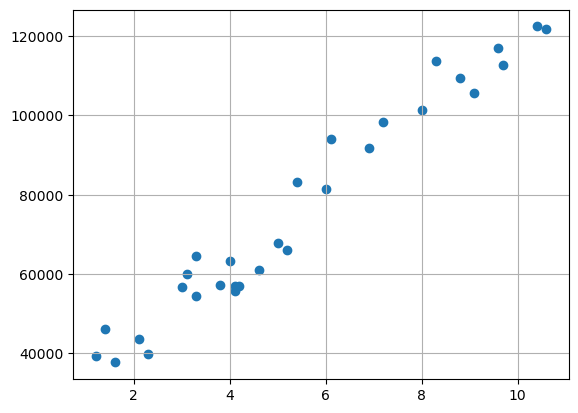

In [21]:
plt.scatter(x,y)
plt.grid()
plt.show()

In [22]:
import seaborn as sns

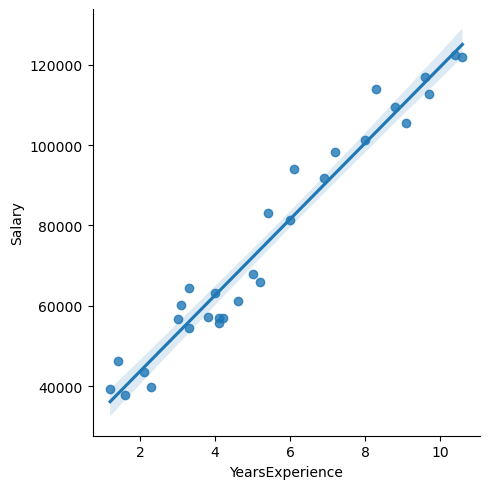

In [23]:
sns.lmplot(data = data, x = "YearsExperience", y = "Salary")

# Here we are splittiing data in two parts Training & Testing

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
# training part == 80%, x_train ,y_train
# testing Part == 20%, x_test, y_test

In [26]:
x_train, x_test,y_train, y_test = train_test_split(x,y, test_size= 0.2, random_state= 42)

In [27]:
x_train.shape

(24, 1)

In [28]:
y_train.shape

(24,)

In [29]:
x_test.shape

(6, 1)

In [30]:
y_test.shape

(6,)

In [31]:
x_train.head()

,YearsExperience
28,10.4
24,8.8
12,4.1
0,1.2
4,2.3


In [32]:
y_train.head()

28    122392.0
24    109432.0
12     56958.0
0      39344.0
4      39892.0
Name: Salary, dtype: float64

In [33]:
from sklearn.linear_model import LinearRegression

In [34]:
model = LinearRegression()
model.fit(x_train,y_train) 

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score

In [36]:
y_pred = model.predict(x_test)

In [37]:
y_test

27    112636.0
15     67939.0
23    113813.0
17     83089.0
8      64446.0
9      57190.0
Name: Salary, dtype: float64

In [38]:
y_pred

array([115791.21011287,  71499.27809463, 102597.86866063,  75268.80422384,
        55478.79204548,  60190.69970699])

In [39]:
r2_score(y_test,y_pred)*100

90.24461774180497

In [40]:
y_pred_train = model.predict(x_train,)

In [41]:
r2_score(y_train,y_pred_train)*100

96.45401573418148

In [42]:
# overfitting == high accuracy on training data and low accuracy on testing data 
# underfitting == low accuracy on training and testing data 

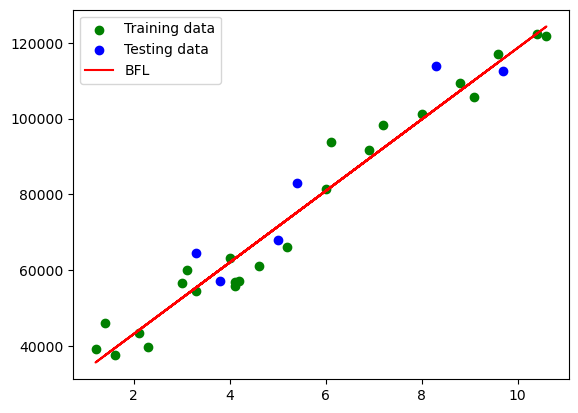

In [43]:
plt.scatter(x_train,y_train, label = "Training data", color = "green")
plt.scatter(x_test,y_test, label = "Testing data", color = "blue")
plt.plot(x_train,y_pred_train ,label="BFL",color = "red")
plt.legend()
plt.show()

In [44]:
# bias / Error

In [45]:
model.predict([[1.4]])

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([37573.54293172])

In [46]:
evaluate = pd.DataFrame(
    {
        "Actual Output" : y_test,
        "Predicted Output" : y_pred,
        "Bias/Error" : y_test - y_pred
    }
)

In [47]:
evaluate

,Actual Output,Predicted Output,Bias/Error
27,112636.0,115791.210113,-3155.210113
15,67939.0,71499.278095,-3560.278095
23,113813.0,102597.868661,11215.131339
17,83089.0,75268.804224,7820.195776
8,64446.0,55478.792045,8967.207955
9,57190.0,60190.699707,-3000.699707


<Axes: >

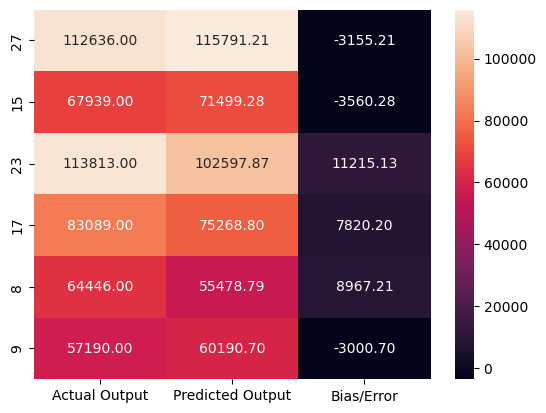

In [48]:
sns.heatmap(evaluate, annot= True, fmt = "0.2f")

In [49]:
# y = mx + c

In [50]:
model.coef_ #m

array([9423.81532303])

In [51]:
model.intercept_ #c

np.float64(24380.20147947369)

In [52]:
model.predict([[1.4]])

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([37573.54293172])

In [53]:
# y = mx + c
9423.81532303*1.4 + 24380.20147947369

37573.54293171569

In [54]:
import joblib

In [55]:
joblib.dump(model,r"C:\Users\sahil\OneDrive\Desktop\ML\SLR.joblib")

['C:\\Users\\sahil\\OneDrive\\Desktop\\ML\\SLR.joblib']